In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import norm

# Plot output directory
plot_dir = os.path.join("..", "plots", "eda")
os.makedirs(plot_dir, exist_ok=True)

In [3]:
np.random.seed(42)

T = 10_000      
K_LAGS = 3      # <--- General AR(k) parameter (e.g., k=3)
ALPHA = 0.05    # 95% Confidence

In [ ]:
""" Parameters for a 2-state AR(k) HMM """

# Regime 0: Low volatility, short memory
# Regime 1: High volatility, long memory (trending)

mu = np.array([0.0, 0.0])
sigma = np.array([0.5, 1.2])

# phi shape: (num_regimes, k_lags)
phi = np.array([
    [0.1, 0.05, 0.02],  # Regime 0 coefficients [lag1, lag2, lag3]
    [0.6, 0.2, 0.1]     # Regime 1 coefficients [lag1, lag2, lag3]
])

P = np.array([
    [0.98, 0.02],
    [0.05, 0.95]
])

states = np.zeros(T, dtype=int)
y = np.zeros(T)

# Initialize first k-steps
states[:K_LAGS] = 0
y[:K_LAGS] = np.random.normal(size=K_LAGS)

In [ ]:
""" Simulation loop for AR(k) """

for t in range(K_LAGS, T):
    # Transition regime
    states[t] = np.random.choice([0, 1], p=P[states[t-1]])
    s = states[t]
    
    # AR(k) part: mu + sum(phi * previous_y)
    lags = y[t-K_LAGS:t][::-1] # Get t-1, t-2... t-k
    y[t] = mu[s] + np.dot(phi[s], lags) + np.random.normal(scale=sigma[s])

print(f"Simulation of AR({K_LAGS}) complete.")

Simulation of AR(3) complete.


In [ ]:
""" Oracle Prediction Intervals for AR(k) """

y_hat = np.zeros(T)
lower = np.zeros(T)
upper = np.zeros(T)

z = norm.ppf(1 - ALPHA / 2)

for t in range(K_LAGS, T):
    s = states[t-1]
    lags = y[t-K_LAGS:t][::-1]
    
    y_hat[t] = mu[s] + np.dot(phi[s], lags)
    lower[t] = y_hat[t] - z * sigma[s]
    upper[t] = y_hat[t] + z * sigma[s]

# Slice results to remove uninitialized start
y_true = y[K_LAGS:]
lo, hi = lower[K_LAGS:], upper[K_LAGS:]

In [ ]:
""" Scoring & Comparison """

def get_metrics(y_true, l, u, alpha=0.05):
    cov = np.mean((y_true >= l) & (y_true <= u))
    wid = np.mean(u - l)
    is_val = np.mean((u - l) + (2/alpha)*np.maximum(l-y_true, 0) + (2/alpha)*np.maximum(y_true-u, 0))
    return cov, wid, is_val

# Baseline 1: Always 0
std_data = np.std(y_true)
l0, u0 = np.zeros_like(y_true) - z*std_data, np.zeros_like(y_true) + z*std_data

# Baseline 2: Repeat Last
l_last, u_last = y[K_LAGS-1:-1] - z*std_data, y[K_LAGS-1:-1] + z*std_data

results = {
    f"AR({K_LAGS})-HMM (Oracle)": get_metrics(y_true, lo, hi),
    "Baseline: Always 0": get_metrics(y_true, l0, u0),
    "Baseline: Repeat Last": get_metrics(y_true, l_last, u_last)
}

print(f"{'Model':<25} | {'Coverage':>8} | {'Avg Width':>10} | {'IS (↓)':>10}")
print("-" * 65)
for name, m in results.items():
    print(f"{name:<25} | {m[0]:>8.4f} | {m[1]:>10.4f} | {m[2]:>10.4f}")

Model                     | Coverage |  Avg Width |     IS (↓)
-----------------------------------------------------------------
AR(3)-HMM (Oracle)        |   0.9454 |     2.7730 |     3.4909
Baseline: Always 0        |   0.9316 |     4.7832 |     8.1813
Baseline: Repeat Last     |   0.9784 |     4.7832 |     5.2827


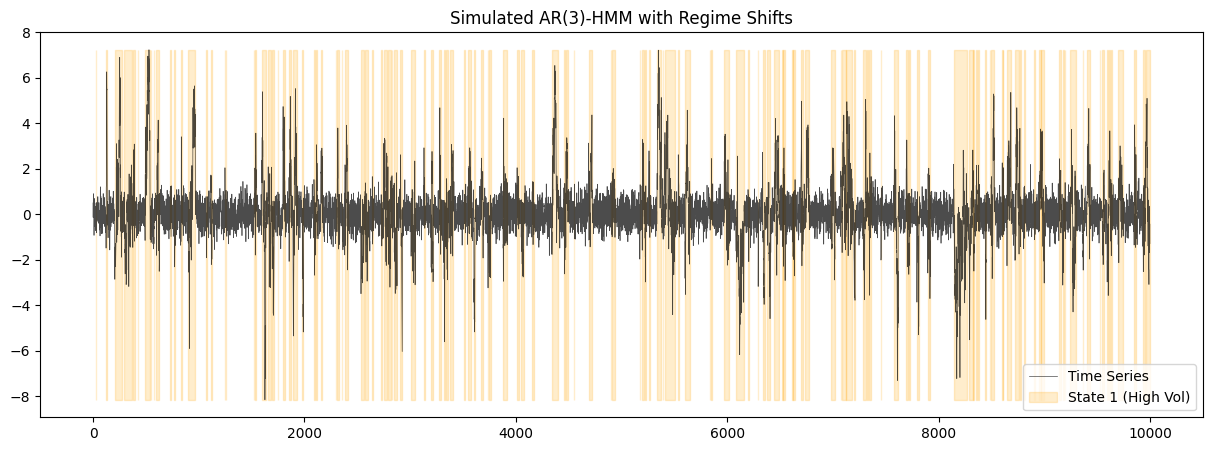

In [ ]:
""" Visualizing Regimes """

plt.figure(figsize=(15, 5))
plt.plot(y, color='black', alpha=0.7, lw=0.5, label='Time Series')
plt.fill_between(range(T), y.min(), y.max(), where=(states==1), color='orange', alpha=0.2, label='State 1 (High Vol)')
plt.title(f"Simulated AR({K_LAGS})-HMM with Regime Shifts")
plt.legend()
plt.show()

In [9]:
""" Final Summary for AR(2)-HMM """

print("=" * 80)
print(f"AR({K_LAGS})-HMM SIMULATION SUMMARY".center(80))
print("=" * 80)

# 1. Process & Param Info
print(f"  Sample Size (T): {T:,}")
print(f"  Target Confidence: {100*(1-ALPHA):.1f}% (alpha={ALPHA})")
print(f"  Transition Matrix P:\n{P}")
print()

# 2. Regime Specific Dynamics
for s in range(len(mu)):
    print(f"  Regime {s}: mu={mu[s]:.2f}, sigma={sigma[s]:.2f}, Lags(phi)={phi[s]}")
    occ = np.sum(states == s)
    print(f"    Occupancy: {occ:,} ({100*occ/T:.1f}%)")
print()

# 3. Performance Table
print("-" * 80)
print(f"{'Model Profile':<30} | {'Coverage':>10} | {'Avg Width':>10} | {'IS (↓ lower)':>12}")
print("-" * 80)

for name, metrics in results.items():
    cov, wid, is_val = metrics
    check = " ✓" if "HMM" in name else ""
    print(f"{name:<30} | {cov:>10.4f} | {wid:>10.4f} | {is_val:>12.4f}{check}")

print("-" * 80)

# 4. Success Check
hmm_score = results[f"AR({K_LAGS})-HMM (Oracle)"][2]
best_baseline = min([results[n][2] for n in results if "HMM" not in n])

if hmm_score < best_baseline:
    improvement = 100 * (best_baseline - hmm_score) / best_baseline
    print(f"  STATUS: SUCCESS. HMM outperformed best baseline by {improvement:.2f}%.")
else:
    print(f"  STATUS: MARGINAL. Check if parameters for States 0 and 1 are too similar.")

print("=" * 80)


                          AR(3)-HMM SIMULATION SUMMARY                          
  Sample Size (T): 10,000
  Target Confidence: 95.0% (alpha=0.05)
  Transition Matrix P:
[[0.98 0.02]
 [0.05 0.95]]

  Regime 0: mu=0.00, sigma=0.50, Lags(phi)=[0.1  0.05 0.02]
    Occupancy: 7,037 (70.4%)
  Regime 1: mu=0.00, sigma=1.20, Lags(phi)=[0.6 0.2 0.1]
    Occupancy: 2,963 (29.6%)

--------------------------------------------------------------------------------
Model Profile                  |   Coverage |  Avg Width | IS (↓ lower)
--------------------------------------------------------------------------------
AR(3)-HMM (Oracle)             |     0.9454 |     2.7730 |       3.4909 ✓
Baseline: Always 0             |     0.9316 |     4.7832 |       8.1813
Baseline: Repeat Last          |     0.9784 |     4.7832 |       5.2827
--------------------------------------------------------------------------------
  STATUS: SUCCESS. HMM outperformed best baseline by 33.92%.
